In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
data = pd.read_csv("household_power_consumption.txt", sep=";")

/var/folders/w1/684s5ms515348ms3yt5nj7_40000gn/T/ipykernel_62401/3483890989.py:1: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("household_power_consumption.txt", sep=";")


In [3]:
df = data.copy()

In [14]:
df['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'], dayfirst=True)
df = df.sort_values('datetime')
df = df.set_index('datetime')

In [6]:
# date range (there is data from 2006 - 2010)
df["datetime"].min(), df["datetime"].max()

(Timestamp('2006-12-16 17:24:00'), Timestamp('2010-11-26 21:02:00'))

In [7]:
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

Text(0.5, 1.0, 'Distribution of Global Active Power')

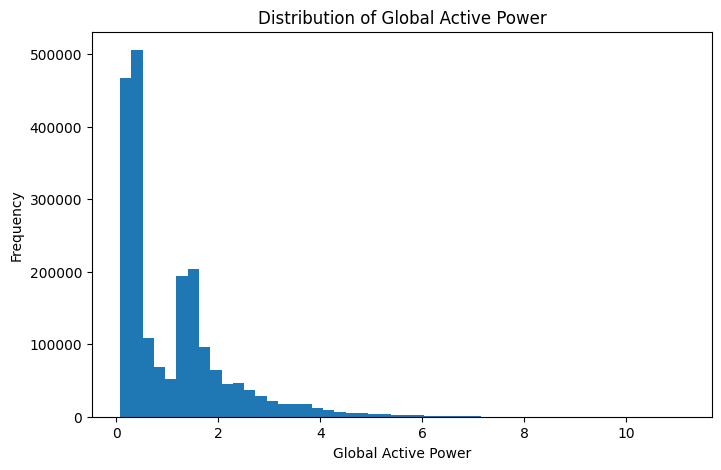

In [9]:
# We are trying to predict Global_active_power

plt.figure(figsize=(8, 5))
plt.hist(df["Global_active_power"], bins=50)
plt.xlabel("Global Active Power")
plt.ylabel("Frequency")
plt.title("Distribution of Global Active Power")


Text(0.5, 1.0, 'Global Active Power Over Time')

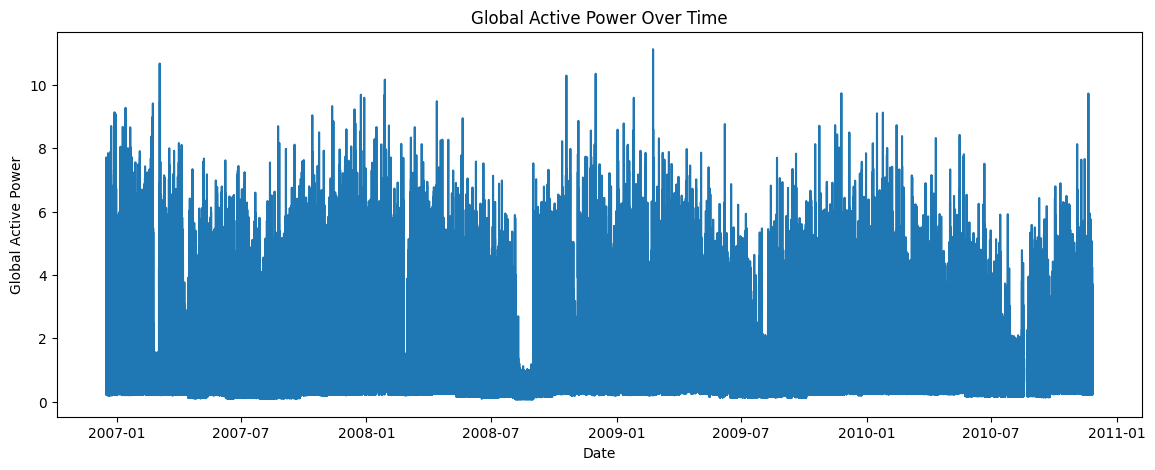

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df['datetime'], df["Global_active_power"])
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.title("Global Active Power Over Time")


Text(0.5, 1.0, 'Daily Average Power Usage')

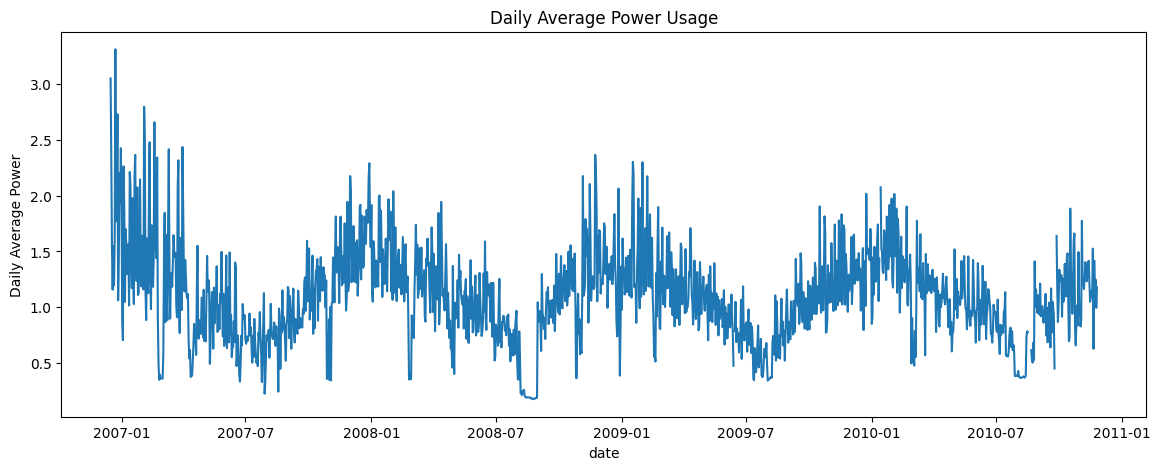

In [16]:
daily_power = df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_power)
plt.xlabel("date")
plt.ylabel("Daily Average Power")
plt.title("Daily Average Power Usage")



Text(0.5, 1.0, 'Weekly Average Power Usage')

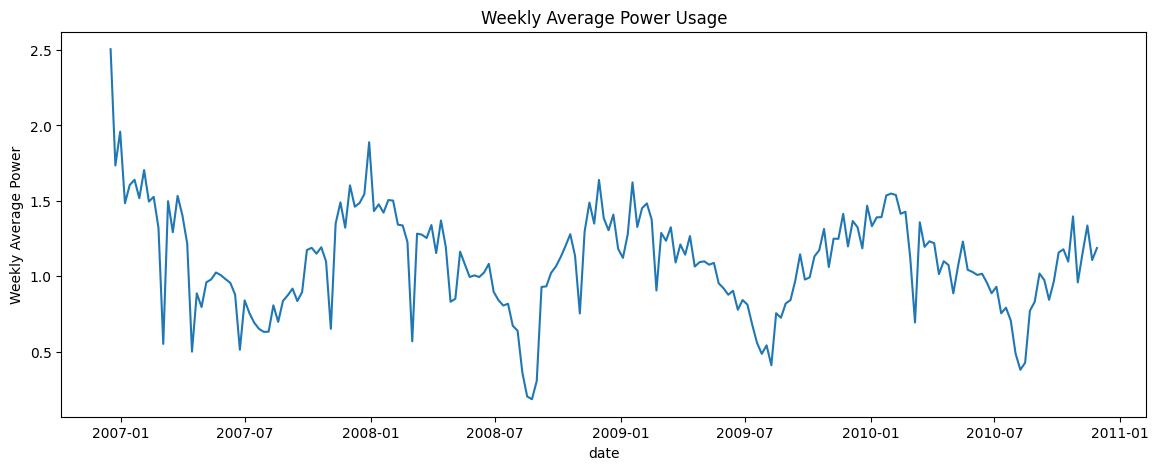

In [17]:
weekly_power = df["Global_active_power"].resample("W").mean()

plt.figure(figsize=(14, 5))
plt.plot(weekly_power)
plt.xlabel("date")
plt.ylabel("Weekly Average Power")
plt.title("Weekly Average Power Usage")

Text(0.5, 1.0, 'Monthly Average Power Usage')

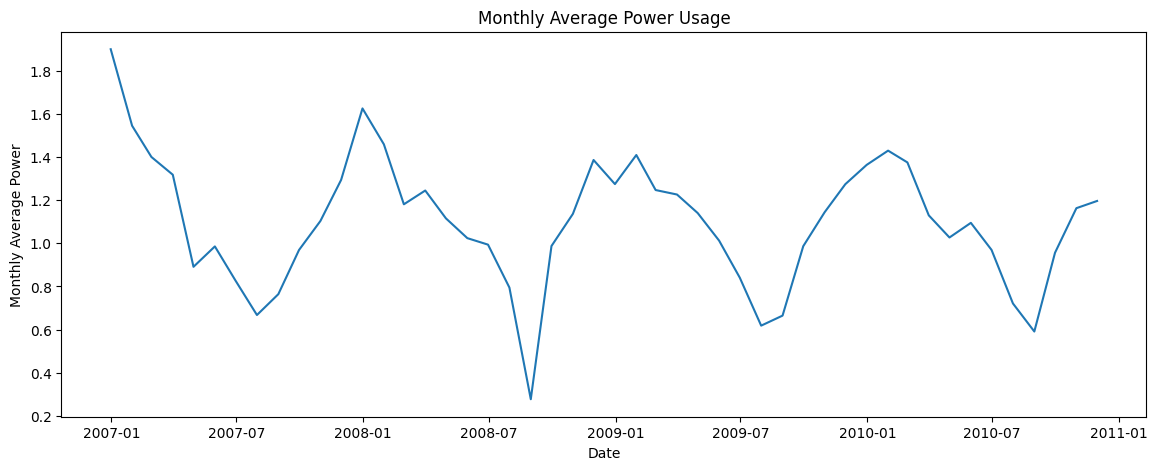

In [18]:
monthly_power = df["Global_active_power"].resample("ME").mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_power)
plt.xlabel("Date")
plt.ylabel("Monthly Average Power")
plt.title("Monthly Average Power Usage")


# based on the graph below, the average monthly power consumption is higher during winters and lower during summers

Text(0.5, 1.0, 'Average Power Usage by Hour')

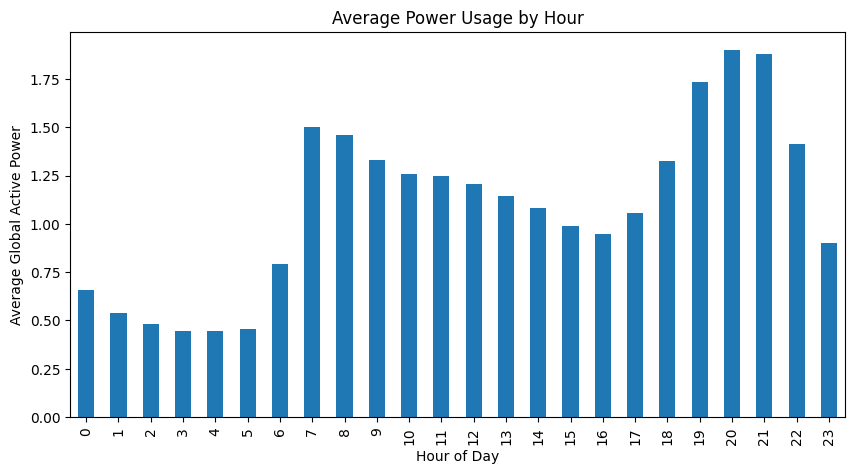

In [19]:
# analyzing average energy consumption by the hour

df['hour'] = df.index.hour

hourly_avg = df.groupby("hour")['Global_active_power'].mean()

plt.figure(figsize=(10,5))
hourly_avg.plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Hour")

Text(0.5, 1.0, 'Average Power Usage by Day of Week')

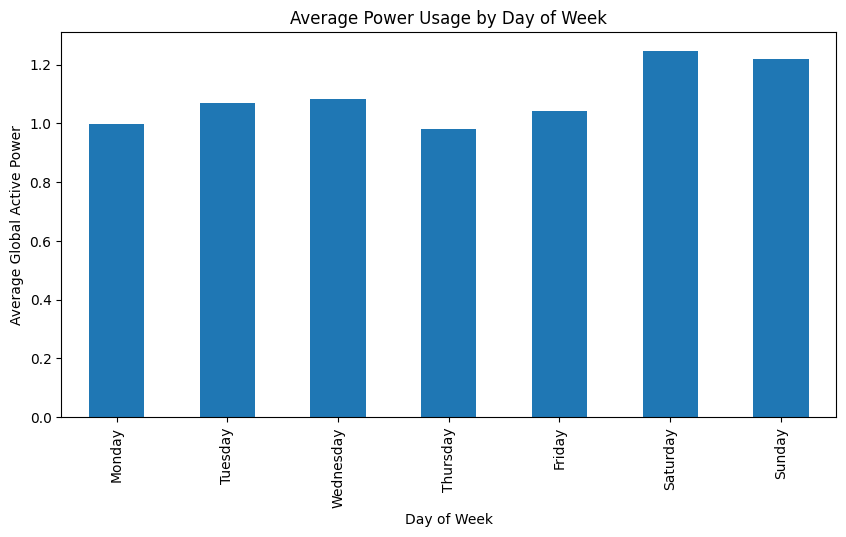

In [20]:
# day of the week pattern  - slightly higher on saturdays and sundays

df['day'] = df.index.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_of_week_avg = df.groupby('day')["Global_active_power"].mean().reindex(order)

plt.figure(figsize=(10,5))
day_of_week_avg.plot(kind='bar')
plt.xlabel("Day of Week")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Day of Week")



Text(0.5, 1.0, 'Average Power Usage by Month')

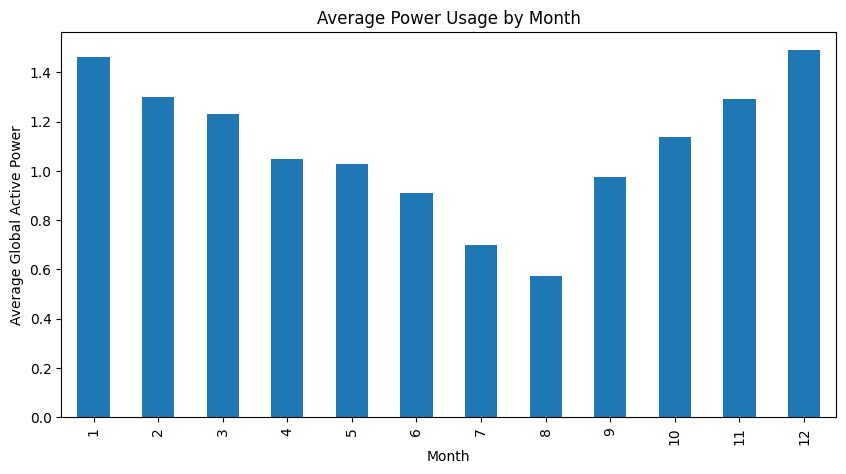

In [21]:
df['month'] = df.index.month

monthly_pattern = df.groupby('month')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
monthly_pattern.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Month")

Text(0.5, 1.0, 'Total Energy by Sub-Metering Area')

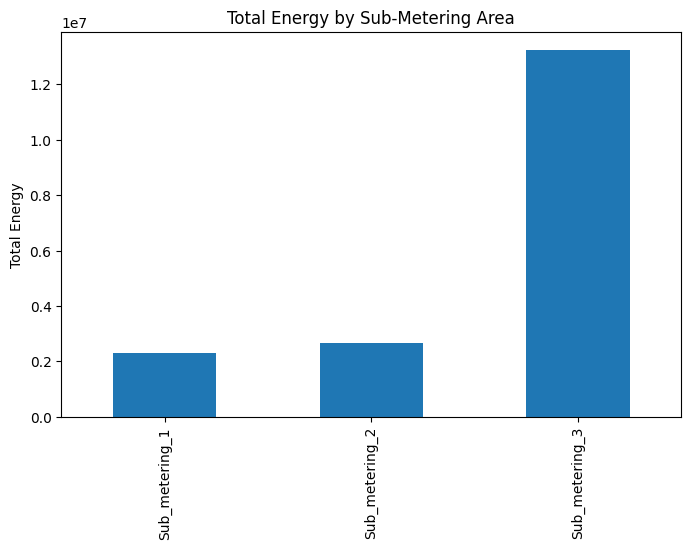

In [ ]:
# sub meter 3 uses the most energy and aub meters 1 and 2 use about the same energy

sub_meter_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df['Sub_metering_1'] = pd.to_numeric(df['Sub_metering_1'], errors="coerce")
df['Sub_metering_2'] = pd.to_numeric(df['Sub_metering_2'], errors="coerce")
df['Sub_metering_3'] = pd.to_numeric(df['Sub_metering_3'], errors="coerce")

df[sub_meter_cols].sum().plot(kind='bar', figsize=(8,5))
plt.ylabel("Total Energy")
plt.title("Total Energy by Sub-Metering Area")

In [31]:
# converting to watts per minute
df["global_active_energy"] = df["Global_active_power"] * 1000 / 60
df['total_metered'] = (df['Sub_metering_1'] + df['Sub_metering_2'] + df["Sub_metering_3"])

df["unmetered_energy"] = df["global_active_energy"] - df["total_metered"]

Text(0.5, 1.0, 'Metered vs Unmetered Energy Over Time')

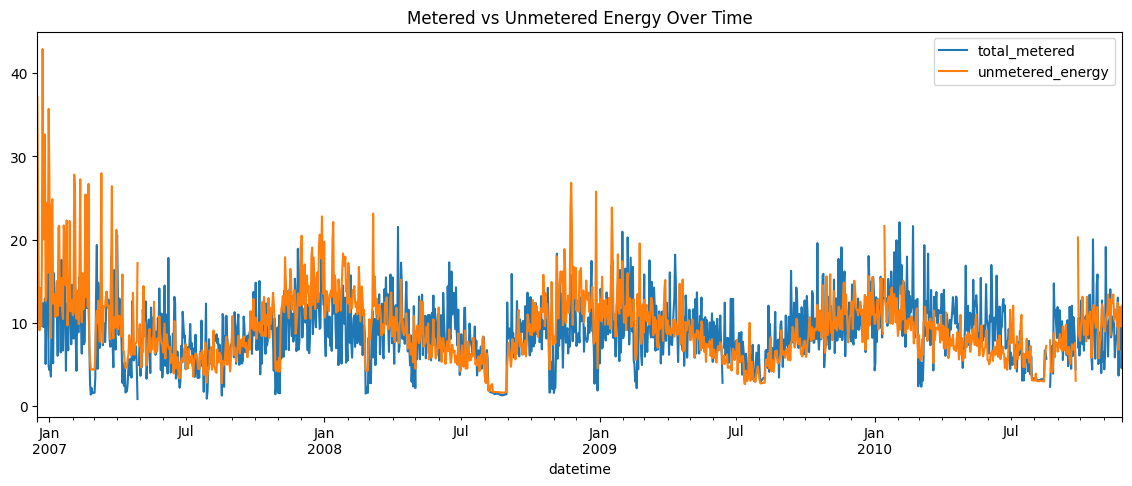

In [44]:
df[["total_metered", "unmetered_energy"]].resample("D").mean().plot(figsize=(14, 5))
plt.title("Metered vs Unmetered Energy Over Time")


In [46]:
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df = df.dropna(subset=numeric_cols)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

corr = df[numeric_cols].corr()
corr["Global_active_power"].sort_values(ascending=False)

Global_active_power      1.000000
Global_intensity         0.998889
Sub_metering_3           0.638555
Sub_metering_1           0.484401
Sub_metering_2           0.434569
Global_reactive_power    0.247017
Voltage                 -0.399762
Name: Global_active_power, dtype: float64

In [47]:
df.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
hour                     0
day                      0
month                    0
total_metered            0
global_active_energy     0
unmetered_energy         0
dtype: int64